### 1-Librerias y reproducibilidad

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reproducibility (best-effort)
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

In [11]:

# -----------------------------------------
# Data acquisition with offline fallback
# -----------------------------------------
DATA_CSV_CANDIDATES = [
    Path("data/BTC-USD.csv"),
    Path("../data/BTC-USD.csv"),
    Path("../../data/BTC-USD.csv"),
    Path("BTC-USD.csv"),
]

def try_load_cached_csv() -> pd.DataFrame | None:
    for p in DATA_CSV_CANDIDATES:
        if p.exists():
            df = pd.read_csv(p, parse_dates=["Date"])
            df = df.set_index("Date").sort_index()
            print(f"✅ Loaded cached BTC data from: {p.resolve()}")
            return df
    return None

df_btc = None

try:
    import yfinance as yf  # pip install yfinance

    df_btc = yf.download("BTC-USD", start="2015-01-01", interval="1d", auto_adjust=False, progress=False)
    if df_btc is None or len(df_btc) == 0:
        raise RuntimeError("Empty download from yfinance.")
    df_btc = df_btc.reset_index().set_index("Date").sort_index()
    print(f"✅ Downloaded BTC-USD from Yahoo Finance. Rows: {len(df_btc)}")

    # Save cache (best-effort) if running in a writable environment
    out_cache = Path("data/BTC-USD.csv")
    try:
        out_cache.parent.mkdir(parents=True, exist_ok=True)
        df_btc.reset_index().to_csv(out_cache, index=False)
        print(f"💾 Cached data saved to: {out_cache.resolve()}")
    except Exception as e:
        print(f"⚠️ Could not write cache file (ok in read-only builds): {e}")

except Exception as e:
    print(f"⚠️ yfinance download failed: {e}")
    df_btc = try_load_cached_csv()

if df_btc is None:
    raise FileNotFoundError(
        "Could not obtain BTC data. "
        "Install yfinance and ensure internet access, OR place a cached file at data/BTC-USD.csv."
    )

# We will use the Close price
if "Close" not in df_btc.columns:
    raise ValueError(f"Expected 'Close' column. Found: {list(df_btc.columns)}")

close = df_btc[["Close"]].dropna().astype(float)
print("Date range:", close.index.min().date(), "→", close.index.max().date())
display(close.head())

✅ Downloaded BTC-USD from Yahoo Finance. Rows: 4115
💾 Cached data saved to: C:\Users\inter\OneDrive - Universidad Externado de Colombia\Tercer Semestre\Topicos de mineria de datos\Talleres\RMR\Codigos\data\BTC-USD.csv
Date range: 2015-01-01 → 2026-04-08


Price,Close
Ticker,BTC-USD
Date,
2015-01-01,314.248993
2015-01-02,315.032013
2015-01-03,281.082001
2015-01-04,264.195007
2015-01-05,274.473999


#### Tendencia diaría de la serie del BTC-USD

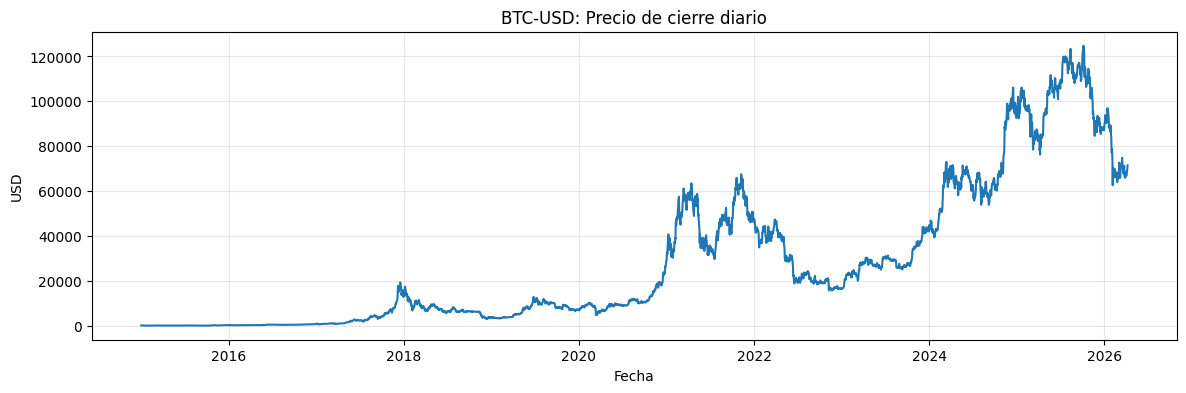

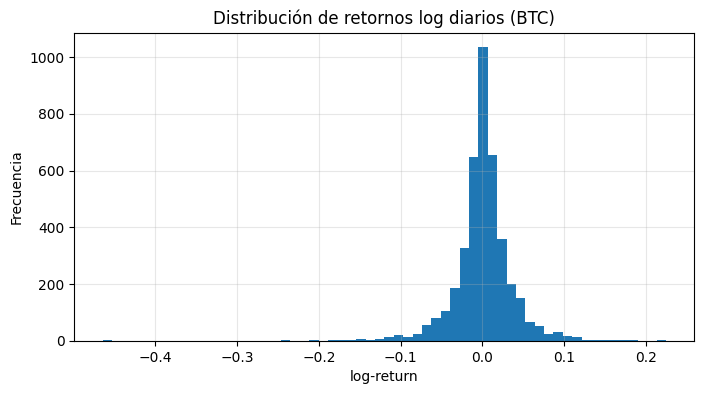

In [12]:

plt.figure(figsize=(14, 4))
plt.plot(close.index, close["Close"].values)
plt.title("BTC-USD: Precio de cierre diario")
plt.xlabel("Fecha")
plt.ylabel("USD")
plt.grid(True, alpha=0.3)
plt.show()

# Volatility hint: daily log-returns distribution
log_returns = np.log(close["Close"]).diff().dropna()
plt.figure(figsize=(8, 4))
plt.hist(log_returns.values, bins=60)
plt.title("Distribución de retornos log diarios (BTC)")
plt.xlabel("log-return")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.show()


### Calculo del retorno logaritmico

In [15]:
# Eliminamos el nivel 'Ticker' para quedarnos solo con ['Close', 'High', etc.]
close.columns = close.columns.get_level_values(0)
#Calculo del retorno logatmico diario
close['Log_Return'] = np.log(close['Close'] / close['Close'].shift(1))

In [16]:
close

Price,Close,Log_Return
Date,,
2015-01-01,314.248993,NaN
2015-01-02,315.032013,0.002489
2015-01-03,281.082001,-0.114028
2015-01-04,264.195007,-0.061959
2015-01-05,274.473999,0.038169
...,...,...
2026-04-03,66931.101562,0.000636
2026-04-04,67290.515625,0.005356
2026-04-05,68981.898438,0.024825


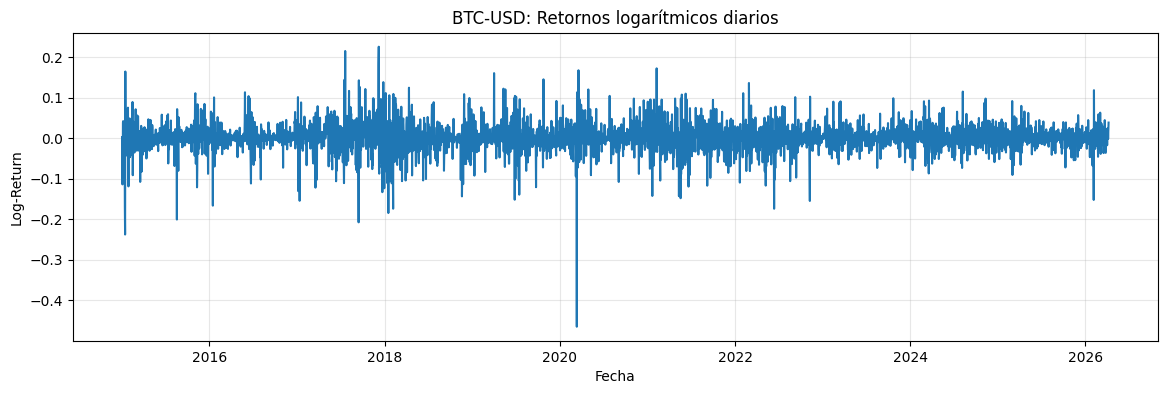

In [18]:

plt.figure(figsize=(14, 4))
plt.plot(close.index, close["Log_Return"].values)
plt.title("BTC-USD: Retornos logarítmicos diarios")
plt.xlabel("Fecha")
plt.ylabel("Log-Return")
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Extraemos la serie como un array 2D de forma (T, 1)
# Usar corchetes dobles [['Log_Return']] asegura que mantenga las 2 dimensiones
data = close[['Log_Return']].values 

# Train/Test split (time-based): 90% / 10%
LOOK_BACK = 60

# Dividimos ANTES de escalar para evitar fuga de datos (Data Leakage)
split_idx = int(len(data) * 0.90)
train_raw = data[:split_idx]
test_raw = data[split_idx:]


# Escalamos los retornos entre 0 y 1
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
test_scaled = scaler.transform(test_raw)

def make_windows(series_2d: np.ndarray, look_back: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Build supervised windows from a univariate series (T, 1).
    Returns: X: (N, look_back, 1), y: (N, 1)
    """
    X_list, y_list = [], []
    for i in range(look_back, len(series_2d)):
        X_list.append(series_2d[i - look_back : i, 0])
        y_list.append(series_2d[i, 0])
        
    X = np.array(X_list, dtype=float).reshape(-1, look_back, 1)
    y = np.array(y_list, dtype=float).reshape(-1, 1)
    return X, y

# Generamos los tensores finales para la RNN
X_train, y_train = make_windows(train_scaled, LOOK_BACK)
X_test, y_test = make_windows(test_scaled, LOOK_BACK)

print("Datos listos para la Red Neuronal:")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape : {X_test.shape}  | y_test shape : {y_test.shape}")

Datos listos para la Red Neuronal:
X_train shape: (3643, 60, 1) | y_train shape: (3643, 1)
X_test shape : (352, 60, 1)  | y_test shape : (352, 1)


In [22]:
# Baseline: predict y_t as the last value in the window (scaled)
baseline_pred_scaled = X_test[:, -1, 0].reshape(-1, 1)

# Back to real prices
y_test_real = scaler.inverse_transform(y_test)
baseline_pred_real = scaler.inverse_transform(baseline_pred_scaled)

def rmse(y_true: np.ndarray, y_hat: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_hat)))

baseline_rmse = rmse(y_test_real, baseline_pred_real)
baseline_mae = float(mean_absolute_error(y_test_real, baseline_pred_real))

print(f"Baseline (tomorrow=today) | RMSE: {baseline_rmse:.2f} | MAE: {baseline_mae:.2f}")

Baseline (tomorrow=today) | RMSE: 0.03 | MAE: 0.02


### Arquitectura: Bidirectional LSTM + Dropout

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Bidirectional(LSTM(units=50, return_sequences=True), input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),
    Bidirectional(LSTM(units=50, return_sequences=False)),
    Dropout(0.2),
    Dense(25, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

c:\Users\inter\miniconda3\envs\redes_neuronales\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 100)        │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 100)            │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,751 (327.15 KB)

 Trainable params: 83,751 (327.15 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del modelo

Epoch 1/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 0.1986 - val_loss: 0.3435 - learning_rate: 0.0010
Epoch 2/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.2767 - val_loss: 0.2114 - learning_rate: 0.0010
Epoch 3/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.1720 - val_loss: 0.1295 - learning_rate: 0.0010
Epoch 4/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.1049 - val_loss: 0.0765 - learning_rate: 0.0010
Epoch 5/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - loss: 0.0617 - val_loss: 0.0431 - learning_rate: 0.0010
Epoch 6/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - loss: 0.0350 - val_loss: 0.0231 - learning_rate: 0.0010
Epoch 7/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - loss: 0.0193 - val_loss: 0.0118 - learning_rate: 0.0010
Epoch 8/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - loss: 0.0107 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 9/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 0.0063 - val_loss: 0.0031 - learning_rate: 0.0010


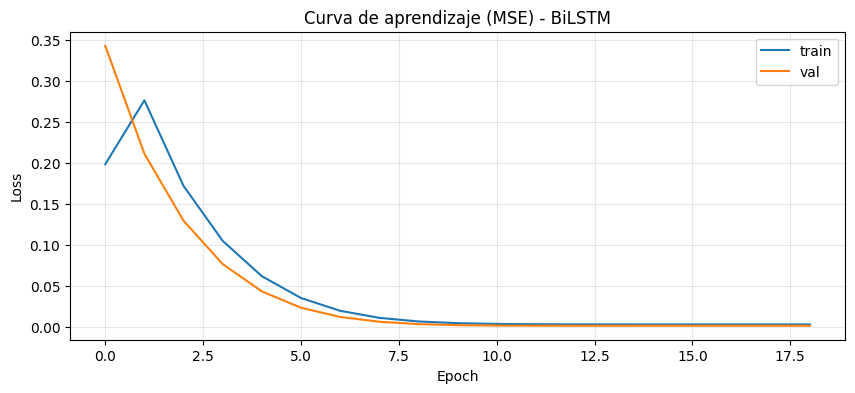

In [24]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Curva de aprendizaje (MSE) - BiLSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Evaluación y visualización

In [ ]:
pred_scaled = model.predict(X_test, verbose=0)

pred_real = scaler.inverse_transform(pred_scaled)
y_test_real = scaler.inverse_transform(y_test)

model_rmse = rmse(y_test_real, pred_real)
model_mae = float(mean_absolute_error(y_test_real, pred_real))

print(f"BiLSTM | RMSE: {model_rmse:.2f} | MAE: {model_mae:.2f}")
print(f"Baseline | RMSE: {baseline_rmse:.2f} | MAE: {baseline_mae:.2f}")

BiLSTM | RMSE: 0.02 | MAE: 0.02
Baseline | RMSE: 0.03 | MAE: 0.02


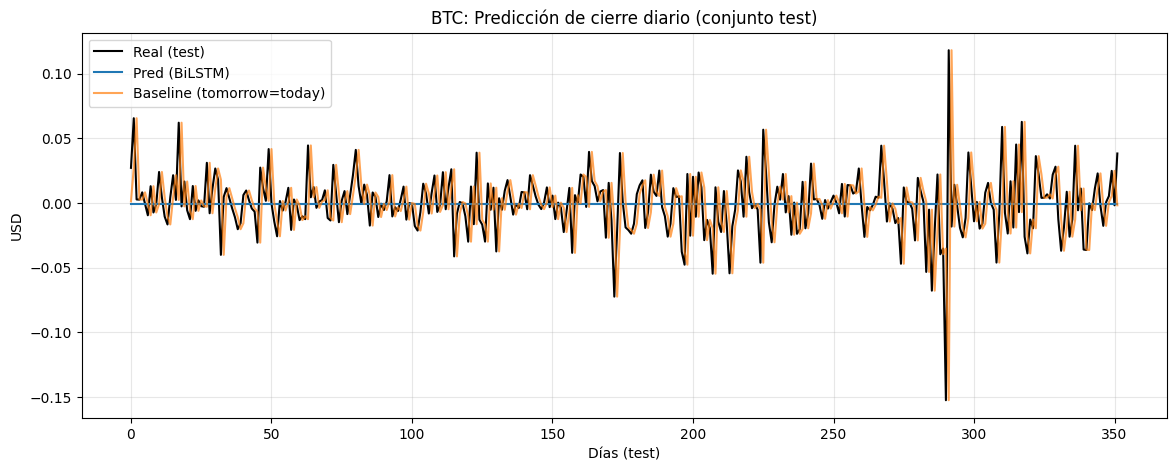

In [26]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_real, color="black", label="Real (test)")
plt.plot(pred_real, label="Pred (BiLSTM)")
plt.plot(baseline_pred_real, label="Baseline (tomorrow=today)", alpha=0.7)
plt.title("BTC: Predicción de cierre diario (conjunto test)")
plt.xlabel("Días (test)")
plt.ylabel("USD")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()